# ETL Nacional - PYMES Colombia (NIIF Pymes)

## Procesamiento Completo de los Estados Financieros SIREM a Nivel Nacional

**Proyecto**: "Diseño e Implementación de un Sistema Web de Análisis Financiero con Modelo de Machine Learning para la Evaluación de Riesgo en PYMES del Municipio de Ibagué, Tolima"

---

### Objetivo

Procesar los **4 datasets completos** del SIREM (Superintendencia de Sociedades) para todas las empresas colombianas bajo **NIIF Pymes**, generando un dataset consolidado nacional. Este dataset será la base de entrenamiento del modelo de Machine Learning.

### Cambio de enfoque

| Aspecto | Enfoque anterior (Ibagué) | Enfoque actual (Nacional) |
|---------|--------------------------|--------------------------|
| Alcance | 61 empresas de Ibagué | **Todas las PYMES NIIF en Colombia** |
| Tamaño del dataset | ~359 observaciones empresa-año | **~200,000+ observaciones** |
| Promedios sectoriales | 61 empresas (no representativo) | **Miles por sector** |
| Metadatos empresa | Cámara de Comercio Ibagué | **Carátula SIREM (nacional)** |
| Rol de Ibagué | Única fuente | Caso de validación (notebook separado) |

### Datasets SIREM

Los 4 archivos comparten la misma estructura de **11 columnas** en formato **vertical** (una fila por cada par concepto-valor):

| Columna | Descripción |
|---------|-------------|
| `CODIGO_INSTANCIA` | Identificador único del reporte |
| `NIT` | Número de Identificación Tributaria (con comas: "900,152,104") |
| `NUMERO_RADICADO` | Número de radicación ante Supersociedades |
| `ID_PUNTO_ENTRADA` | ID numérico del tipo de reporte NIIF |
| `PUNTO_ENTRADA` | Tipo de reporte: "NIIF Pymes" vs "NIIF Plenas" |
| `ID_TAXONOMIA` | ID numérico de la taxonomía |
| `TAXONOMIA` | Año fiscal en texto (truncada para 2021+: "Corte 202") |
| `FECHA_CORTE` | Fecha completa del cierre fiscal ("2023 Dec 31 12:00:00 AM") |
| `CONCEPTO` | Nombre de la cuenta contable |
| `PERIODO` | Tipo de periodo: "Periodo Actual", "Periodo Anterior", fechas |
| `VALOR` | Valor numérico (financieros) o texto (Carátula) |

### Lecciones de notebooks anteriores

1. **Usar `FECHA_CORTE`** (no `TAXONOMIA`) para extraer el año fiscal — TAXONOMIA está truncada para 2021+
2. **Filtro inteligente de `PERIODO`** — maneja formatos mixtos ("Periodo Actual" vs "2016-dic-31")
3. **Encoding `latin-1`** para archivos SIREM financieros (UTF-8 puede funcionar para Carátula)
4. **NIT de 9 dígitos** sin dígito de verificación en SIREM

### Proceso ETL (paso a paso)

```
Carátula (metadatos) ─────────────────────────────────────┐
                                                           │
Situación Financiera ──┐                                   │
                       │                                   │
Resultado Integral ────┤── Pivotear cada uno ──► Merge ◄───┘
                       │                          │
Flujo de Efectivo ─────┘                          │
                                                  ▼
                                    Dataset Consolidado Nacional
```

In [1]:
# ==============================================================================
# IMPORTACION DE LIBRERIAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gc
import time

# Configuracion general
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 6)

print('Librerias cargadas correctamente')

C:\Users\USUARIO1\AppData\Local\Temp\ipykernel_22300\3233378717.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Librerias cargadas correctamente


---
## 1. Configuración y Vista General de los Datos

Verificamos que todos los archivos fuente estén disponibles y mostramos un panorama general del volumen de datos a procesar.

In [2]:
# ==============================================================================
# CONFIGURACION DE RUTAS
# ==============================================================================

BASE_PATH = Path('C:/Users/USUARIO1/Documents/Tesis/dataset')
SALIDA_PATH = Path('C:/Users/USUARIO1/Documents/Tesis/data')
SALIDA_PATH.mkdir(exist_ok=True)

# Los 4 datasets SIREM
ARCHIVOS = {
    'caratula': 'Estados_Financieros_NIIF-_Carátula_20260204.csv',
    'situacion_financiera': 'Estados_Financieros_NIIF-_Estado_de_Situación_Financiera_20260203.csv',
    'resultado_integral': 'Estados_Financieros_NIIF-_Estado_de_Resultado_Integral_20260204.csv',
    'flujo_efectivo': 'Estados_Financieros_NIIF-_Estado_de_Flujo_Efectivo_20260204.csv'
}

# Verificar archivos y mostrar panorama general
print('PANORAMA GENERAL DE LOS DATOS')
print('=' * 70)
total_gb = 0
for nombre, archivo in ARCHIVOS.items():
    ruta = BASE_PATH / archivo
    if ruta.exists():
        tamano_gb = ruta.stat().st_size / (1024**3)
        total_gb += tamano_gb
        print(f'  [OK] {nombre:<25s} {tamano_gb:.2f} GB')
    else:
        print(f'  [ERROR] {nombre}: NO ENCONTRADO')
        print(f'          Ruta esperada: {ruta}')

print(f'{"":>28s} --------')
print(f'{"TOTAL":>28s} {total_gb:.2f} GB')
print(f'\nCarpeta de salida: {SALIDA_PATH}')

PANORAMA GENERAL DE LOS DATOS
  [OK] caratula                  2.07 GB
  [OK] situacion_financiera      4.10 GB
  [OK] resultado_integral        1.57 GB
  [OK] flujo_efectivo            1.43 GB
                             --------
                       TOTAL 9.17 GB

Carpeta de salida: C:\Users\USUARIO1\Documents\Tesis\data


---
## 2. Funciones Auxiliares

Definimos funciones pequeñas y enfocadas para las operaciones que se repiten en cada dataset. Cada una hace **una sola cosa** y se invoca explícitamente en el flujo de procesamiento, manteniendo la visibilidad de cada paso.

| Función | Qué hace |
|---------|----------|
| `limpiar_nit()` | Elimina comas del NIT, deja solo dígitos de 9 caracteres |
| `extraer_anio()` | Extrae el año fiscal de FECHA_CORTE (ej: "2023 Dec 31..." → 2023) |
| `filtrar_periodo()` | Remueve "Periodo Anterior" y periodos comparativos |
| `analizar_cobertura()` | Muestra empresas por año y profundidad temporal |
| `pivotar_estado()` | Transforma formato vertical → horizontal |

In [3]:
# ==============================================================================
# FUNCIONES AUXILIARES
# ==============================================================================

def limpiar_nit(df):
    """
    Limpia el campo NIT del SIREM.

    El SIREM almacena los NITs con comas como separador de miles
    (ej: "900,152,104"). Esta funcion elimina todo caracter no numerico
    y deja el NIT como cadena de 9 digitos.

    Args:
        df: DataFrame con columna 'NIT'

    Returns:
        DataFrame con nueva columna 'NIT_LIMPIO'
    """
    df['NIT_LIMPIO'] = df['NIT'].astype(str).str.replace('[^0-9]', '', regex=True)
    n_empresas = df['NIT_LIMPIO'].nunique()
    longitudes = df['NIT_LIMPIO'].str.len().value_counts().sort_index()

    print(f'  NIT limpiado: {n_empresas:,} empresas unicas')
    print(f'  Longitudes de NIT: {longitudes.to_dict()}')
    return df


def extraer_anio(df):
    """
    Extrae el anio fiscal desde la columna FECHA_CORTE.

    FECHA_CORTE tiene formato "2023 Dec 31 12:00:00 AM".
    Se extraen los primeros 4 digitos como anio fiscal.

    Esto reemplaza el metodo anterior (extraer de TAXONOMIA) que
    fallaba para 2021+ porque la taxonomia esta truncada como "Corte 202".

    Args:
        df: DataFrame con columna 'FECHA_CORTE'

    Returns:
        DataFrame con nueva columna 'ANIO' (Int64, nullable)
    """
    df['ANIO'] = df['FECHA_CORTE'].str.extract('([0-9]{4})')[0].astype('Int64')
    n_sin_anio = df['ANIO'].isna().sum()
    anios = sorted(df['ANIO'].dropna().unique().tolist())

    print(f'  Anios extraidos: {anios}')
    if n_sin_anio > 0:
        print(f'  ADVERTENCIA: {n_sin_anio:,} filas sin anio valido')
    return df


def filtrar_periodo(df, nombre=''):
    """
    Remueve registros de periodos comparativos para evitar duplicacion.

    En SIREM, cada empresa-anio puede tener:
    - "Periodo Actual": datos del anio fiscal corriente (2018+)
    - "Periodo Anterior": mismos datos pero del anio previo (duplicado)
    - Fechas como "2016-dic-31": periodo corriente para 2016-2017
    - Fechas como "2015-dic-31": periodo comparativo para 2016

    Esta funcion REMUEVE:
    1. Filas donde PERIODO contiene "Anterior" (comparativo explicito)
    2. Filas donde PERIODO es una fecha/anio que NO coincide con ANIO
       (ej: "2015-dic-31" cuando ANIO=2016 = comparativo)

    CONSERVA:
    - "Periodo Actual"
    - Fechas que coinciden con ANIO (ej: "2016-dic-31" cuando ANIO=2016)
    - Valores anomalos como NITs en PERIODO (datos validos con campo corrupto)

    Args:
        df: DataFrame con columnas 'PERIODO' y 'ANIO'
        nombre: Nombre del dataset (para logging)

    Returns:
        DataFrame filtrado (copia)
    """
    antes = len(df)
    periodo_str = df['PERIODO'].astype(str)
    anio_str = df['ANIO'].astype(str)

    # 1. Remover "Periodo Anterior"
    es_anterior = periodo_str.str.contains('anterior', case=False, na=False)

    # 2. Remover fechas/anios que no coinciden con el anio fiscal
    #    Patron: 4 digitos seguidos de guion o fin de cadena
    #    Captura: "2015-dic-31", "2015", "2016", "2017"
    #    NO captura: NITs como "800077198" (mas de 4 digitos sin guion)
    es_fecha_o_anio = periodo_str.str.match('^[0-9]{4}(-|$)', na=False)
    anio_coincide = periodo_str.str[:4] == anio_str
    es_comparativo = es_fecha_o_anio & ~anio_coincide

    mask_remover = es_anterior | es_comparativo
    n_removidas = mask_remover.sum()
    resultado = df[~mask_remover].copy()

    print(f'  Filtro de PERIODO ({nombre}):')
    print(f'    Antes: {antes:,} -> Despues: {len(resultado):,} (removidas: {n_removidas:,})')

    if n_removidas > 0:
        detalle = df.loc[mask_remover, 'PERIODO'].value_counts().head(6)
        for per, cnt in detalle.items():
            print(f'      "{per}": {cnt:,}')

    return resultado


def analizar_cobertura(df, nombre=''):
    """
    Analiza la cobertura temporal del dataset: empresas por anio y
    profundidad temporal por empresa.
    """
    print(f'\nCOBERTURA TEMPORAL ({nombre})')
    print('-' * 50)

    # Empresas por anio
    print(f'\n  Empresas por anio:')
    ea = df.groupby('ANIO')['NIT_LIMPIO'].nunique().sort_index()
    for anio, n in ea.items():
        print(f'    {int(anio)}: {n:,}')

    # Profundidad temporal
    anios_emp = df.groupby('NIT_LIMPIO')['ANIO'].nunique()
    print(f'\n  Profundidad temporal por empresa:')
    print(f'    Minimo:   {anios_emp.min()} anio(s)')
    print(f'    Maximo:   {anios_emp.max()} anio(s)')
    print(f'    Promedio: {anios_emp.mean():.1f}')
    print(f'    Mediana:  {anios_emp.median():.0f}')

    # Total empresa-anio
    n_ea = df.groupby(['NIT_LIMPIO', 'ANIO']).ngroups
    print(f'\n  Total combinaciones empresa-anio: {n_ea:,}')
    return ea


def pivotar_estado(df, nombre=''):
    """
    Pivotea un estado financiero del formato vertical al horizontal.

    Entrada (vertical):
    | NIT_LIMPIO | ANIO | CONCEPTO              | VALOR     |
    |------------|------|-----------------------|-----------|
    | 890702298  | 2023 | Activos corrientes    | 1,500,000 |
    | 890702298  | 2023 | Pasivos corrientes    | 800,000   |

    Salida (horizontal):
    | NIT_LIMPIO | ANIO | Activos corrientes | Pasivos corrientes |
    |------------|------|--------------------|--------------------|
    | 890702298  | 2023 | 1,500,000          | 800,000            |

    Duplicados se resuelven con aggfunc='first' (primer valor encontrado).
    """
    print(f'\nPIVOTEO ({nombre})')
    print('-' * 50)

    # Asegurar VALOR numerico
    df['VALOR'] = pd.to_numeric(df['VALOR'], errors='coerce')

    # Verificar duplicados
    dups = df.groupby(['NIT_LIMPIO', 'ANIO', 'CONCEPTO']).size()
    n_dups = (dups > 1).sum()
    print(f'  Duplicados NIT+ANIO+CONCEPTO: {n_dups:,} de {len(dups):,} ({n_dups/len(dups)*100:.1f}%)')
    if n_dups > 0:
        print(f'  (se resuelven con aggfunc="first")')

    # Pivotar
    t0 = time.time()
    pivotado = df.pivot_table(
        index=['NIT_LIMPIO', 'ANIO'],
        columns='CONCEPTO',
        values='VALOR',
        aggfunc='first'
    ).reset_index()
    pivotado.columns.name = None
    t_pivot = time.time() - t0

    print(f'\n  Resultado: {pivotado.shape[0]:,} filas x {pivotado.shape[1]} columnas')
    print(f'  Tiempo de pivoteo: {t_pivot:.1f}s')

    # Completitud
    n_vals = pivotado.iloc[:, 2:].notna().sum().sum()
    n_total = pivotado.shape[0] * (pivotado.shape[1] - 2)
    completitud = n_vals / n_total * 100 if n_total > 0 else 0
    print(f'  Completitud: {completitud:.1f}% ({n_vals:,} de {n_total:,} celdas)')

    return pivotado


print('Funciones auxiliares definidas:')
print('  limpiar_nit(), extraer_anio(), filtrar_periodo()')
print('  analizar_cobertura(), pivotar_estado()')

Funciones auxiliares definidas:
  limpiar_nit(), extraer_anio(), filtrar_periodo()
  analizar_cobertura(), pivotar_estado()


---
## 3. Carátula — Metadatos de Empresas

La **Carátula** contiene información de identificación de las empresas: razón social, actividad económica (CIIU), dirección, municipio, departamento, etc. Está en el mismo formato vertical que los estados financieros, pero el campo `VALOR` es **tipo texto** (no numérico).

### Diferencias con los estados financieros

| Aspecto | Carátula | Estados Financieros |
|---------|----------|---------------------|
| Tipo de VALOR | Texto (nombres, códigos) | Numérico (cifras en pesos) |
| Filtro PERIODO | No aplica | Remover "Periodo Anterior" |
| Resultado del pivoteo | 1 fila por empresa (último dato) | 1 fila por empresa-año |
| Uso | Identificación y clasificación | Cálculo de indicadores |

### Propósito

Reemplaza a la Cámara de Comercio como fuente de metadatos, ya que cubre **todas** las empresas NIIF Pymes a nivel nacional (no solo Ibagué).

In [4]:
# ==============================================================================
# 3.1 CARGA DE LA CARATULA
# ==============================================================================

print('CARGA DE LA CARATULA')
print('=' * 70)

ruta_caratula = BASE_PATH / ARCHIVOS['caratula']
tamano_gb = ruta_caratula.stat().st_size / (1024**3)
print(f'Archivo: {ARCHIVOS["caratula"]}')
print(f'Tamano:  {tamano_gb:.2f} GB')

# Intentar UTF-8 primero (funciono en notebooks anteriores para Caratula)
print(f'\nCargando dataset completo...')
t0 = time.time()
try:
    df_car = pd.read_csv(ruta_caratula, encoding='utf-8', low_memory=False)
    encoding_car = 'utf-8'
except UnicodeDecodeError:
    df_car = pd.read_csv(ruta_caratula, encoding='latin-1', low_memory=False)
    encoding_car = 'latin-1'

print(f'Cargado en {time.time()-t0:.0f}s')
print(f'Encoding: {encoding_car}')
print(f'\nDimensiones: {df_car.shape[0]:,} filas x {df_car.shape[1]} columnas')
print(f'\nColumnas y tipos de datos:')
for col in df_car.columns:
    print(f'  {col:<25s} {str(df_car[col].dtype):<10s}  (ejemplo: {df_car[col].iloc[0]})')

print(f'\nMuestra de los primeros 5 registros:')
display(df_car.head())

CARGA DE LA CARATULA
Archivo: Estados_Financieros_NIIF-_Carátula_20260204.csv
Tamano:  2.07 GB

Cargando dataset completo...
Cargado en 21s
Encoding: utf-8

Dimensiones: 8,685,453 filas x 11 columnas

Columnas y tipos de datos:
  CODIGO_INSTANCIA          object      (ejemplo: 283,724)
  NIT                       object      (ejemplo: 900,152,104)
  NUMERO_RADICADO           object      (ejemplo: 2022-01-056028)
  ID_PUNTO_ENTRADA          int64       (ejemplo: 304)
  PUNTO_ENTRADA             object      (ejemplo: 40 NIIF Pymes - Individuales)
  ID_TAXONOMIA              int64       (ejemplo: 300)
  TAXONOMIA                 object      (ejemplo: 01 - Estados Financieros de Fin de Ejercicio - Corte 2020)
  FECHA_CORTE               object      (ejemplo: 2020 Dec 31 12:00:00 AM)
  CONCEPTO                  object      (ejemplo: La Entidad posee inversiones en subsidiarias, asociadas y/o negocios conjuntos?)
  PERIODO                   object      (ejemplo: Periodo Actual)
  VALOR      

,CODIGO_INSTANCIA,NIT,NUMERO_RADICADO,ID_PUNTO_ENTRADA,PUNTO_ENTRADA,ID_TAXONOMIA,TAXONOMIA,FECHA_CORTE,CONCEPTO,PERIODO,VALOR
0,"283,724","900,152,104",2022-01-056028,304,40 NIIF Pymes - Individuales,300,01 - Estados Financieros de Fin de Ejercicio - Corte 2020,2020 Dec 31 12:00:00 AM,"La Entidad posee inversiones en subsidiarias, asociadas y/o negocios conjuntos?",Periodo Actual,false
1,"283,715","900,251,584",2022-01-056026,304,40 NIIF Pymes - Individuales,300,01 - Estados Financieros de Fin de Ejercicio - Corte 2020,2020 Dec 31 12:00:00 AM,La sociedad es,Periodo Actual,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES
2,"48,161","900,897,386",2017-01-223561,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Objeto social principal,900897386,"MANUFACTURA,EXPORTACION,IMPORTACI{ON,COMPRA,VENTA,DISTRIBUCION,COMERCIALIZAC..."
3,"283,727","804,012,730",2022-01-055992,304,40 NIIF Pymes - Individuales,300,01 - Estados Financieros de Fin de Ejercicio - Corte 2020,2020 Dec 31 12:00:00 AM,Corte de cuentas seg�n estatutos,Periodo Actual,01. ANUAL
4,"283,714","800,149,334",2022-01-056034,304,40 NIIF Pymes - Individuales,300,01 - Estados Financieros de Fin de Ejercicio - Corte 2020,2020 Dec 31 12:00:00 AM,El Revisor fiscal pertenece a una firma?,Periodo Actual,false


In [5]:
# ==============================================================================
# 3.2 EXPLORAR Y FILTRAR NIIF PYMES
# ==============================================================================

# Distribucion de PUNTO_ENTRADA (NIIF Plenas vs Pymes)
print('DISTRIBUCION DE PUNTO_ENTRADA')
print('=' * 70)
pe_dist = df_car['PUNTO_ENTRADA'].value_counts()
for pe, cnt in pe_dist.items():
    pct = cnt / len(df_car) * 100
    print(f'  {pe}: {cnt:,} ({pct:.1f}%)')

# Filtrar NIIF Pymes
print(f'\nFILTRANDO NIIF PYMES...')
n_antes = len(df_car)
df_car = df_car[df_car['PUNTO_ENTRADA'].str.contains('Pymes', case=False, na=False)].copy()
print(f'  Antes: {n_antes:,} -> Despues: {len(df_car):,} ({len(df_car)/n_antes*100:.1f}% del total)')

# Limpiar NIT
print(f'\nLIMPIANDO NIT...')
df_car = limpiar_nit(df_car)

# Extraer anio
print(f'\nEXTRAYENDO ANIO FISCAL...')
df_car = extraer_anio(df_car)

DISTRIBUCION DE PUNTO_ENTRADA
  40 NIIF Pymes - Individual Grupo 2: 3,989,911 (45.9%)
  40 NIIF Pymes - Individuales: 2,368,708 (27.3%)
  10 NIIF Plenas - Individual Grupo 1: 529,007 (6.1%)
  10 NIIF Plenas - Individuales: 401,043 (4.6%)
  50 NIIF Pymes - Separado Grupo 2: 380,253 (4.4%)
  50 NIIF Pymes - Separados: 252,952 (2.9%)
  20 NIIF Plenas - Separado Grupo 1: 202,519 (2.3%)
  20 NIIF Plenas - Separados: 149,418 (1.7%)
  60 NIIF Pymes - Consolidado Grupo 2: 128,831 (1.5%)
  30 NIIF Plenas - Consolidado Grupo 1: 106,535 (1.2%)
  60 NIIF Pymes - Consolidados: 82,333 (0.9%)
  30 NIIF Plenas - Consolidados: 72,380 (0.8%)
  30 NIIF Plenas - Consolidado: 8,496 (0.1%)
  35 NIIF Plenas - Combinado Grupo 1: 7,987 (0.1%)
  65 NIIF Pymes - Combinado Grupo 2: 5,080 (0.1%)

FILTRANDO NIIF PYMES...
  Antes: 8,685,453 -> Despues: 7,208,068 (83.0% del total)

LIMPIANDO NIT...
  NIT limpiado: 38,245 empresas unicas
  Longitudes de NIT: {9: 7208068}

EXTRAYENDO ANIO FISCAL...
  Anios extraidos: [

In [6]:
# ==============================================================================
# 3.3 CONCEPTOS DISPONIBLES EN LA CARATULA
# ==============================================================================

# Los CONCEPTOS de la Caratula son campos de metadatos (no cuentas contables)
conceptos_caratula = sorted(df_car['CONCEPTO'].unique())

print(f'CONCEPTOS EN LA CARATULA ({len(conceptos_caratula)} conceptos)')
print('=' * 70)
for i, c in enumerate(conceptos_caratula, 1):
    n_empresas = df_car[df_car['CONCEPTO'] == c]['NIT_LIMPIO'].nunique()
    # Mostrar un ejemplo del VALOR para entender el contenido
    ejemplo = df_car[df_car['CONCEPTO'] == c]['VALOR'].dropna().iloc[0] if df_car[df_car['CONCEPTO'] == c]['VALOR'].notna().any() else 'N/A'
    ejemplo_corto = str(ejemplo)[:50]
    print(f'  {i:3d}. {c:<55s} ({n_empresas:,} emp.)  ej: "{ejemplo_corto}"')

CONCEPTOS EN LA CARATULA (55 conceptos)
    1. A que firma pertenece el Revisor Fiscal?                (10,966 emp.)  ej: "AMC AUDIT SA"
    2. Alguna de las combinadas posee inversiones en asociadas (103 emp.)  ej: "true"
    3. Alguna de las combinadas posee inversiones en negocios conjuntos (103 emp.)  ej: "false"
    4. Alguna de las entidades consolidadas posee inversiones en asociadas (924 emp.)  ej: "false"
    5. Alguna de las entidades consolidadas posee inversiones en negocios conjuntos (924 emp.)  ej: "false"
    6. CAPITULO X:�Durante el a�o correspondiente al corte de la informaci�n que est� presentando, la empresa desarroll� actividades inmobiliarias, se dedic� habitualmente a la comercializaci�n de metales preciosos y piedras preciosas o realiz� actividades con (25,183 emp.)  ej: "false"
    7. CAPITULO XIII:�Durante el a�o correspondiente al corte de la informaci�n que est� presentando, la empresa realiz� negocios o transacciones internacionales o celebr� contratos con 

In [7]:
# ==============================================================================
# 3.4 SELECCIONAR METADATOS RELEVANTES, PIVOTAR Y GUARDAR
# ==============================================================================

# Seleccionar conceptos por palabras clave
KEYWORDS_METADATA = [
    'social', 'razon', 'nombre',
    'ciiu', 'actividad', 'economica',
    'departamento',
    'municipio', 'ciudad', 'domicilio',
    'direccion', 'dirección',
    'tamano', 'tamaño',
    'tipo', 'sociedad',
    'correo', 'email',
    'telefono', 'teléfono',
]

conceptos_seleccionados = [
    c for c in conceptos_caratula
    if any(kw in c.lower() for kw in KEYWORDS_METADATA)
]

# Fallback: si no se encontraron, conservar todos
if not conceptos_seleccionados:
    print('ADVERTENCIA: No se encontraron conceptos por keywords. Se conservan todos.')
    conceptos_seleccionados = conceptos_caratula

print(f'CONCEPTOS SELECCIONADOS ({len(conceptos_seleccionados)} de {len(conceptos_caratula)})')
print('=' * 70)
for c in conceptos_seleccionados:
    print(f'  - {c}')

# Filtrar y pivotar
df_meta = df_car[df_car['CONCEPTO'].isin(conceptos_seleccionados)].copy()
print(f'\nFilas con conceptos seleccionados: {len(df_meta):,}')

# Ordenar por anio para que aggfunc='last' tome el valor mas reciente
df_meta = df_meta.sort_values('ANIO')

print(f'Pivotando metadatos (1 fila por empresa, valor mas reciente)...')
metadata = df_meta.pivot_table(
    index='NIT_LIMPIO',
    columns='CONCEPTO',
    values='VALOR',
    aggfunc='last'
).reset_index()
metadata.columns.name = None

print(f'\nResultado: {metadata.shape[0]:,} empresas x {metadata.shape[1]} columnas')

# Guardar
archivo_meta = SALIDA_PATH / 'colombia_metadata_pymes.csv'
metadata.to_csv(archivo_meta, index=False, encoding='utf-8')
print(f'Guardado: {archivo_meta.name} ({archivo_meta.stat().st_size/(1024**2):.1f} MB)')

# Liberar Caratula cruda (pesada) pero conservar metadata (pequena)
del df_car, df_meta
gc.collect()
print('Caratula cruda liberada de memoria. Metadata conservada.')

print(f'\nMuestra de metadatos:')
display(metadata.head())

CONCEPTOS SELECCIONADOS (24 de 55)
  - CAPITULO X:�Durante el a�o correspondiente al corte de la informaci�n que est� presentando, la empresa desarroll� actividades inmobiliarias, se dedic� habitualmente a la comercializaci�n de metales preciosos y piedras preciosas o realiz� actividades con
  - Ciudad (Municipio) de notificaci�n f�sica
  - Ciudad de la direcci�n de notificaci�n judicial
  - Ciudad de la direcci�n del domicilio
  - Clasificaci�n Industrial Internacional Uniforme Versi�n 4 A.C (CIIU)
  - De conformidad con lo dispuesto en el art�culo 56 del CPACA, el suscrito autoriza a la Superintendencia de Sociedades para que, a partir de la fecha de presentaci�n del informe, realice la notificaci�n electr�nica de los actos administrativos que corresp
  - Departamento de la direcci�n de notificaci�n judicial
  - Departamento de la direcci�n del domicilio
  - Departamento de notificaci�n f�sica
  - Direcci�n del domicilio
  - Domicilio casa matriz sucursal de sociedad extranjera
  - D

,NIT_LIMPIO,"CAPITULO X:�Durante el a�o correspondiente al corte de la informaci�n que est� presentando, la empresa desarroll� actividades inmobiliarias, se dedic� habitualmente a la comercializaci�n de metales preciosos y piedras preciosas o realiz� actividades con",Ciudad (Municipio) de notificaci�n f�sica,Ciudad de la direcci�n de notificaci�n judicial,Ciudad de la direcci�n del domicilio,Clasificaci�n Industrial Internacional Uniforme Versi�n 4 A.C (CIIU),"De conformidad con lo dispuesto en el art�culo 56 del CPACA, el suscrito autoriza a la Superintendencia de Sociedades para que, a partir de la fecha de presentaci�n del informe, realice la notificaci�n electr�nica de los actos administrativos que corresp",Departamento de la direcci�n de notificaci�n judicial,Departamento de la direcci�n del domicilio,Departamento de notificaci�n f�sica,Direcci�n del domicilio,Domicilio casa matriz sucursal de sociedad extranjera,Domicilio del controlante o casa matriz,E-mail de la sociedad,El M�ximo �rgano Social aprob� distribuir utilidades del ejercicio inmediatamente anterior,El actual informe corresponde a un Estado Financiero de tipo:,En virtud del art�culo 56 del CPACA: �Autoriza a la Superintendencia de Sociedades a la notificaci�n electr�nica de los actos administrativos?,La sociedad es,Nombre o raz�n social del controlante o matriz,Objeto social principal,Pa�s del domicilio casa matriz sucursal de sociedad extranjera,Pa�s del domicilio del controlante o casa matriz,Raz�n social de la sociedad,Tel�fono del domicilio,Tipo societario
0,800000090,false,NaN,MEDELLIN-ANTIOQUIA,MEDELLIN-ANTIOQUIA,F4111 - Construcci�n de edificios residenciales,NaN,ANTIOQUIA,ANTIOQUIA,NaN,Calle 26 N� 38 � 26 Edificio Bio 26,NaN,NaN,ADMINISTRACION@INSERCO.COM.CO,false,NaN,true,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES,NaN,CONSTRUCCION,NaN,NaN,INGENIEROS SERVICIOS CONSTRUCTIVOS SAS,6044442485,08. SOCIEDAD POR ACCIONES SIMPLIFICADA SAS
1,800000154,NaN,NaN,BOGOTA D.C.,BOGOTA D.C.,C2920 - Fabricaci�n de carrocer�as para veh�culos automotores; fabricaci�n d...,true,BOGOTA D.C.,BOGOTA D.C.,NaN,CRA 63 18A 80,NaN,NaN,ventas@carroceriassuper.com,false,NaN,true,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES,NaN,Fabricaci�n de carrocer�as para vehiculos automotores; fabricaci�n de remolq...,NaN,NaN,CONSTRUCCIONES INDUSTRIALES Y SERVICIOS SUPER SAS,3106755012,08. SOCIEDAD POR ACCIONES SIMPLIFICADA SAS
2,800000241,false,NaN,CALI-VALLE,CALI-VALLE,C3290 - Otras industrias manufactureras n.c.p.,true,VALLE,VALLE,NaN,KM 5.5 VIA LA BUITRERA PREDIO LA CANANEA,NaN,NaN,"velas@misvelas.com , ernestocadavid@hotmail.com",false,NaN,true,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES,NaN,LA PRODUCCION Y VENTA DE ARTICULOS DE PARAFINA PARA ELALUMBRADO PUBLICO O PR...,NaN,NaN,CERERIA EL SAGRADO CORAZON LTDA,6023259196,03. SOCIEDAD LIMITADA
3,800000268,true,NaN,BARRANQUILLA-ATLANTICO,BARRANQUILLA-ATLANTICO,L6810 - Actividades inmobiliarias realizadas con bienes propios o arrendados,true,ATLANTICO,ATLANTICO,NaN,Carrera 53 82 115,NaN,NaN,anamariadonado@hotmail.com,false,NaN,true,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES,NaN,Actividad INMOBILIARIA,NaN,NaN,Inversiones Schlegel Donado SAS,3730542,08. SOCIEDAD POR ACCIONES SIMPLIFICADA SAS
4,800000276,false,NaN,BUCARAMANGA-SANTANDER,BUCARAMANGA-SANTANDER,A0145 - Cr�a de aves de corral,true,SANTANDER,SANTANDER,NaN,KM 6 VIA GIRON CR 12 # 57 - 88,NaN,NaN,avicampo@avicolaelmadrono.com,false,NaN,true,07. ACTIVIDAD ECON�MICA DIFERENTE A LAS ANTERIORES,NaN,CRIA DE AVES DE CORRAL,NaN,NaN,AVICOLA EL MADRO�O SA,3183490177,01. SOCIEDAD AN�NIMA


---
## 4. Estado de Situación Financiera (Balance General)

El **Balance General** es el dataset más grande (4.10 GB, ~17.8M filas). Presenta la **posición financiera** de cada empresa en un momento dado:

- **Activos**: lo que la empresa posee o controla
- **Pasivos**: lo que la empresa debe
- **Patrimonio**: lo que pertenece a los socios (Activos - Pasivos)

### Conceptos clave para indicadores financieros

| Concepto | Para qué indicadores |
|----------|---------------------|
| Activos corrientes totales | Razón corriente, Prueba ácida, Capital de trabajo |
| Total de activos | ROA, Rotación de activos, Razón de deuda |
| Pasivos corrientes totales | Razón corriente, Capital de trabajo |
| Total pasivos | Razón de deuda, Deuda/Patrimonio |
| Patrimonio total | ROE, Apalancamiento |
| Inventarios corrientes | Prueba ácida, Rotación de inventarios |
| Efectivo y equivalentes | Razón de efectivo |
| Cuentas por cobrar corrientes | Rotación de cartera |

Este es el dataset que procesamos con **máximo detalle**. Los otros dos siguen el mismo patrón.

In [8]:
# ==============================================================================
# 4.1 CARGA DEL ESTADO DE SITUACION FINANCIERA
# ==============================================================================

print('CARGA: ESTADO DE SITUACION FINANCIERA')
print('=' * 70)

ruta_sf = BASE_PATH / ARCHIVOS['situacion_financiera']
print(f'Archivo: {ARCHIVOS["situacion_financiera"]}')
print(f'Tamano:  {ruta_sf.stat().st_size/(1024**3):.2f} GB')

print(f'\nCargando dataset completo (todas las columnas)...')
t0 = time.time()
df_sf = pd.read_csv(ruta_sf, encoding='latin-1', low_memory=False)
print(f'Cargado en {time.time()-t0:.0f}s')
print(f'\nDimensiones: {df_sf.shape[0]:,} filas x {df_sf.shape[1]} columnas')

print(f'\nColumnas y tipos:')
for col in df_sf.columns:
    print(f'  {col:<25s} {str(df_sf[col].dtype):<10s}')

print(f'\nMuestra:')
display(df_sf.head())

CARGA: ESTADO DE SITUACION FINANCIERA
Archivo: Estados_Financieros_NIIF-_Estado_de_Situación_Financiera_20260203.csv
Tamano:  4.10 GB

Cargando dataset completo (todas las columnas)...
Cargado en 43s

Dimensiones: 17,851,220 filas x 11 columnas

Columnas y tipos:
  CODIGO_INSTANCIA          object    
  NIT                       object    
  NUMERO_RADICADO           object    
  ID_PUNTO_ENTRADA          int64     
  PUNTO_ENTRADA             object    
  ID_TAXONOMIA              int64     
  TAXONOMIA                 object    
  FECHA_CORTE               object    
  CONCEPTO                  object    
  PERIODO                   object    
  VALOR                     float64   

Muestra:


,CODIGO_INSTANCIA,NIT,NUMERO_RADICADO,ID_PUNTO_ENTRADA,PUNTO_ENTRADA,ID_TAXONOMIA,TAXONOMIA,FECHA_CORTE,CONCEPTO,PERIODO,VALOR
0,"18,275","830,010,665",2017-01-072472,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Cuentas comerciales por cobrar y otras cuentas por cobrar corrientes,2015-dic-31,"42,988.00"
1,"18,275","830,010,665",2017-01-072472,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Pasivos corrientes totales,2015-ene-01,"90,431.00"
2,"18,275","830,010,665",2017-01-072472,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Pasivos corrientes totales,2016-dic-31,"498,672.00"
3,"18,275","830,010,665",2017-01-072472,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Pasivos corrientes totales,2015-dic-31,"216,673.00"
4,"18,275","830,010,665",2017-01-072472,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Activos corrientes totales,2015-ene-01,"121,705.00"


In [9]:
# ==============================================================================
# 4.2 DISTRIBUCION NIIF Y FILTRADO
# ==============================================================================

print('DISTRIBUCION DE PUNTO_ENTRADA')
print('=' * 70)
pe_dist = df_sf['PUNTO_ENTRADA'].value_counts()
for pe, cnt in pe_dist.items():
    pct = cnt / len(df_sf) * 100
    barra = '#' * int(pct / 2)
    print(f'  {pe}')
    print(f'    {cnt:>12,} registros ({pct:.1f}%) {barra}')

print(f'\nFILTRANDO NIIF PYMES...')
n_antes = len(df_sf)
df_sf = df_sf[df_sf['PUNTO_ENTRADA'].str.contains('Pymes', case=False, na=False)].copy()
print(f'  {n_antes:,} -> {len(df_sf):,} filas ({len(df_sf)/n_antes*100:.1f}%)')

DISTRIBUCION DE PUNTO_ENTRADA
  40 NIIF Pymes - Individual Grupo 2
       6,758,346 registros (37.9%) ##################
  40 NIIF Pymes - Individuales
       6,150,075 registros (34.5%) #################
  10 NIIF Plenas - Individuales
       1,008,426 registros (5.6%) ##
  10 NIIF Plenas - Individual Grupo 1
         925,006 registros (5.2%) ##
  50 NIIF Pymes - Separado Grupo 2
         660,486 registros (3.7%) #
  50 NIIF Pymes - Separados
         659,558 registros (3.7%) #
  20 NIIF Plenas - Separados
         383,781 registros (2.1%) #
  20 NIIF Plenas - Separado Grupo 1
         374,512 registros (2.1%) #
  60 NIIF Pymes - Consolidado Grupo 2
         254,802 registros (1.4%) 
  60 NIIF Pymes - Consolidados
         231,392 registros (1.3%) 
  30 NIIF Plenas - Consolidado Grupo 1
         223,629 registros (1.3%) 
  30 NIIF Plenas - Consolidados
         192,833 registros (1.1%) 
  35 NIIF Plenas - Combinado Grupo 1
          17,558 registros (0.1%) 
  65 NIIF Pymes - Combinado

In [10]:
# ==============================================================================
# 4.3 LIMPIEZA DE NIT
# ==============================================================================

print('LIMPIEZA DE NIT')
print('=' * 70)

# Mostrar formato original
print(f'Formato original del NIT (con comas):')
print(f'  Ejemplo: "{df_sf["NIT"].iloc[0]}"')
print(f'  Con comas: {df_sf["NIT"].astype(str).str.contains(",").sum():,} de {len(df_sf):,}')

# Limpiar
df_sf = limpiar_nit(df_sf)

# Verificar que todos son de 9 digitos
print(f'\n  Todas las empresas SIREM tienen NIT de 9 digitos: ',
      f'{"SI" if (df_sf["NIT_LIMPIO"].str.len() == 9).all() else "NO"}')

LIMPIEZA DE NIT
Formato original del NIT (con comas):
  Ejemplo: "830,010,665"
  Con comas: 14,725,475 de 14,725,475
  NIT limpiado: 38,233 empresas unicas
  Longitudes de NIT: {9: 14725475}

  Todas las empresas SIREM tienen NIT de 9 digitos:  SI


In [11]:
# ==============================================================================
# 4.4 EXPLORACION TEMPORAL: TAXONOMIA vs FECHA_CORTE vs PERIODO
# ==============================================================================

# Esta exploracion demuestra POR QUE usamos FECHA_CORTE en lugar de TAXONOMIA

print('EXPLORACION TEMPORAL')
print('=' * 70)

# --- TAXONOMIA ---
print(f'\n>>> TAXONOMIA ({df_sf["TAXONOMIA"].nunique()} valores unicos):')
for tax, cnt in df_sf['TAXONOMIA'].value_counts().sort_index().items():
    truncada = ' *** TRUNCADA (no contiene anio completo)' if tax.strip().endswith('202') else ''
    print(f'  {tax}')
    print(f'    {cnt:,} filas{truncada}')

filas_truncadas = df_sf[df_sf['TAXONOMIA'].str.strip().str.endswith('202')].shape[0]
print(f'\n  >> {filas_truncadas:,} filas ({filas_truncadas/len(df_sf)*100:.1f}%) tienen TAXONOMIA truncada')
print(f'  >> Estas filas corresponden a 2021-2024 y se perderian si usaramos TAXONOMIA')

# --- FECHA_CORTE ---
print(f'\n>>> FECHA_CORTE ({df_sf["FECHA_CORTE"].nunique()} valores unicos):')
for fc, cnt in df_sf['FECHA_CORTE'].value_counts().sort_index().items():
    print(f'  {fc}: {cnt:,} filas')

print(f'\n  >> FECHA_CORTE contiene el anio completo para TODOS los registros')
print(f'  >> Por eso la usamos como fuente del anio fiscal')

# --- PERIODO ---
print(f'\n>>> PERIODO ({df_sf["PERIODO"].nunique()} valores unicos):')
for per, cnt in df_sf['PERIODO'].value_counts().items():
    print(f'  "{per}": {cnt:,} filas')

print(f'\n  >> "Periodo Anterior" es el comparativo del anio previo (genera duplicacion)')
print(f'  >> Las fechas "2015-xxx" y "2016-xxx" son el formato de 2016-2017')

EXPLORACION TEMPORAL

>>> TAXONOMIA (7 valores unicos):
  01 - Estados Financieros de Fin de Ejercicio - Corte 201
    9,023 filas
  01 - Estados Financieros de Fin de Ejercicio - Corte 202
    7,834,219 filas *** TRUNCADA (no contiene anio completo)
  01- Estados Financieros de Fin de Ejercicio - Corte 2016
    2,043,239 filas
  01- Estados Financieros de Fin de Ejercicio - Corte 2017
    1,099,821 filas
  01- Estados Financieros de Fin de Ejercicio - Corte 2018
    1,022,105 filas
  01- Estados Financieros de Fin de Ejercicio - Corte 2019
    1,345,205 filas
  01- Estados Financieros de Fin de Ejercicio - Corte 2020
    1,371,863 filas

  >> 7,834,219 filas (53.2%) tienen TAXONOMIA truncada
  >> Estas filas corresponden a 2021-2024 y se perderian si usaramos TAXONOMIA

>>> FECHA_CORTE (71 valores unicos):
  2016 Dec 31 12:00:00 AM: 2,039,491 filas
  2016 Jul 31 12:00:00 AM: 75 filas
  2016 Jun 30 12:00:00 AM: 3,013 filas
  2016 Mar 31 12:00:00 AM: 128 filas
  2016 Nov 30 12:00:00 AM:

In [12]:
# ==============================================================================
# 4.5 EXTRACCION DEL ANIO FISCAL
# ==============================================================================

print('EXTRACCION DEL ANIO FISCAL DESDE FECHA_CORTE')
print('=' * 70)

df_sf = extraer_anio(df_sf)

# Distribucion por anio
print(f'\nDistribucion de registros por anio:')
for anio, cnt in df_sf.groupby('ANIO').size().sort_index().items():
    n_emp = df_sf[df_sf['ANIO'] == anio]['NIT_LIMPIO'].nunique()
    print(f'  {int(anio)}: {cnt:>8,} registros  ({n_emp:,} empresas)')

EXTRACCION DEL ANIO FISCAL DESDE FECHA_CORTE
  Anios extraidos: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Distribucion de registros por anio:
  2016: 2,043,239 registros  (19,703 empresas)
  2017: 1,099,857 registros  (16,419 empresas)
  2018: 1,022,456 registros  (15,947 empresas)
  2019: 1,353,832 registros  (21,859 empresas)
  2020: 1,522,036 registros  (25,391 empresas)
  2021: 1,516,002 registros  (25,214 empresas)
  2022: 3,118,708 registros  (26,925 empresas)
  2023: 1,608,152 registros  (26,966 empresas)
  2024: 1,441,193 registros  (24,077 empresas)


In [13]:
# ==============================================================================
# 4.6 FILTRADO DE PERIODO
# ==============================================================================

print('FILTRADO DE PERIODO ACTUAL')
print('=' * 70)

df_sf = filtrar_periodo(df_sf, 'Situacion Financiera')

# Verificar que no quedan registros sin anio
n_sin_anio = df_sf['ANIO'].isna().sum()
if n_sin_anio > 0:
    print(f'\nEliminando {n_sin_anio:,} filas sin anio valido...')
    df_sf = df_sf.dropna(subset=['ANIO'])

print(f'\nDataset post-filtrado: {len(df_sf):,} filas, {df_sf["NIT_LIMPIO"].nunique():,} empresas')

FILTRADO DE PERIODO ACTUAL
  Filtro de PERIODO (Situacion Financiera):
    Antes: 14,725,475 -> Despues: 7,061,409 (removidas: 7,664,066)
      "Periodo Anterior": 5,782,770
      "2015-dic-31": 690,227
      "2015-ene-01": 642,103
      "2016-dic-31": 541,454
      "2015-Dec-31": 2,270
      "2015-Jan-01": 1,991

Dataset post-filtrado: 7,061,409 filas, 38,233 empresas



COBERTURA TEMPORAL (Situacion Financiera)
--------------------------------------------------

  Empresas por anio:
    2016: 19,703
    2017: 16,419
    2018: 15,947
    2019: 21,859
    2020: 25,391
    2021: 25,214
    2022: 26,925
    2023: 26,966
    2024: 24,077

  Profundidad temporal por empresa:
    Minimo:   1 anio(s)
    Maximo:   9 anio(s)
    Promedio: 5.3
    Mediana:  6

  Total combinaciones empresa-anio: 202,501


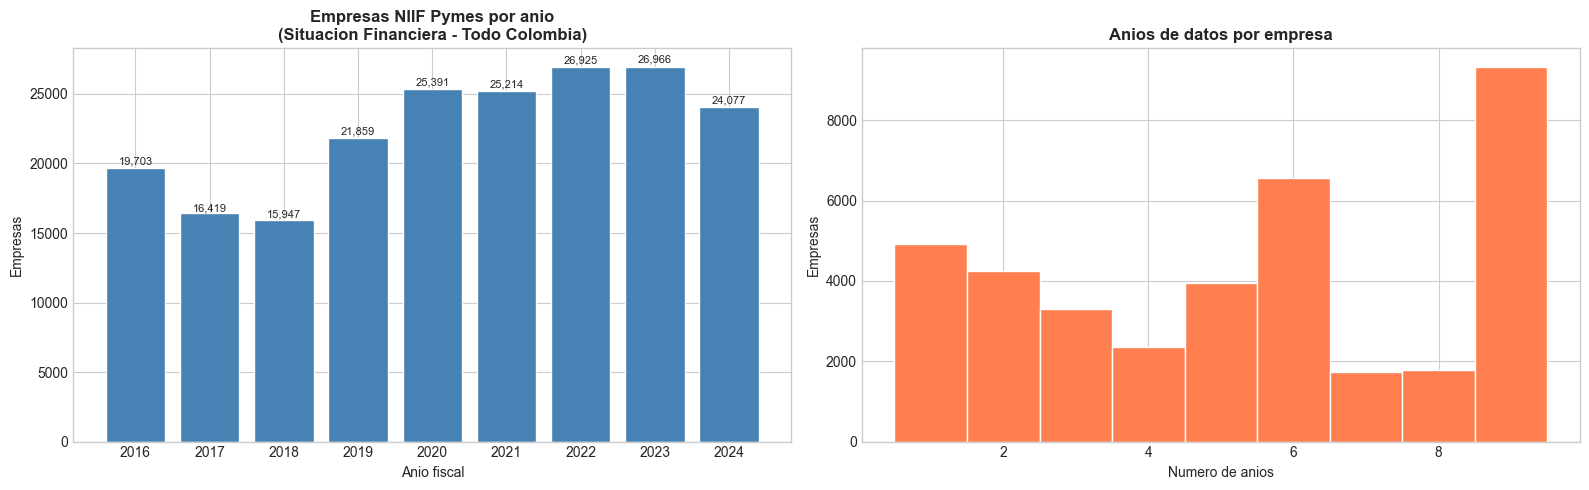

In [14]:
# ==============================================================================
# 4.7 ANALISIS DE COBERTURA TEMPORAL
# ==============================================================================

ea_sf = analizar_cobertura(df_sf, 'Situacion Financiera')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Empresas por anio
axes[0].bar(ea_sf.index.astype(int).astype(str), ea_sf.values, color='steelblue', edgecolor='white')
axes[0].set_title('Empresas NIIF Pymes por anio\n(Situacion Financiera - Todo Colombia)', fontweight='bold')
axes[0].set_xlabel('Anio fiscal')
axes[0].set_ylabel('Empresas')
for i, v in enumerate(ea_sf.values):
    axes[0].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=8)

# Profundidad temporal
anios_emp = df_sf.groupby('NIT_LIMPIO')['ANIO'].nunique()
axes[1].hist(anios_emp, bins=range(1, anios_emp.max()+2), color='coral', edgecolor='white', align='left')
axes[1].set_title('Anios de datos por empresa', fontweight='bold')
axes[1].set_xlabel('Numero de anios')
axes[1].set_ylabel('Empresas')

plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# 4.8 CONCEPTOS CONTABLES DISPONIBLES
# ==============================================================================

conceptos_sf = sorted(df_sf['CONCEPTO'].unique())

# Conceptos clave para indicadores
CLAVE_SF = [
    'Activos corrientes totales',
    'Total de activos',
    'Pasivos corrientes totales',
    'Total pasivos',
    'Patrimonio total',
    'Inventarios corrientes',
    'Efectivo y equivalentes',
    'Cuentas comerciales por cobrar',
    'Ganancias acumuladas',
    'Propiedades, planta y equipo',
]

print(f'CONCEPTOS EN SITUACION FINANCIERA ({len(conceptos_sf)} conceptos)')
print('=' * 70)
for i, c in enumerate(conceptos_sf, 1):
    es_clave = any(kw.lower() in c.lower() for kw in CLAVE_SF)
    marca = ' <<<< CLAVE PARA INDICADORES' if es_clave else ''
    print(f'  {i:3d}. {c}{marca}')

# Verificar presencia de conceptos clave
print(f'\nVERIFICACION DE CONCEPTOS CLAVE:')
for kw in CLAVE_SF:
    encontrado = [c for c in conceptos_sf if kw.lower() in c.lower()]
    if encontrado:
        print(f'  [OK] "{kw}" -> {encontrado[0]}')
    else:
        print(f'  [!!] "{kw}" -> NO ENCONTRADO')

CONCEPTOS EN SITUACION FINANCIERA (80 conceptos)
    1. Acciones propias en cartera
    2. Activos
    3. Activos biolï¿½gicos corrientes, al costo menos depreciaciï¿½n acumulada y deterioro de valor
    4. Activos biolï¿½gicos corrientes, al valor razonable
    5. Activos biolï¿½gicos no corrientes, al costo menos depreciaciï¿½n acumulada y deterioro del valor
    6. Activos biolï¿½gicos no corrientes, al valor razonable
    7. Activos corrientes
    8. Activos corrientes distintos al efectivo pignorados como garantï¿½a colateral para la cual el receptor de la transferencia tiene derecho por contrato o costumbre a vender o pignorar nuevamente la garantï¿½a colateral
    9. Activos corrientes distintos al efectivo pignorados como garantï¿½a colateral para las que el receptor de transferencias tiene derecho por contrato o costumbre a vender o pignorar de nuevo dicha garantï¿½a colateral
   10. Activos corrientes totales <<<< CLAVE PARA INDICADORES
   11. Activos intangibles distintos de

In [16]:
# ==============================================================================
# 4.9 PIVOTEO Y GUARDADO
# ==============================================================================

pivotado_sf = pivotar_estado(df_sf, 'Situacion Financiera')

# Guardar
archivo_sf = SALIDA_PATH / 'colombia_situacion_financiera_pymes.csv'
pivotado_sf.to_csv(archivo_sf, index=False, encoding='utf-8')
print(f'\nGuardado: {archivo_sf.name} ({archivo_sf.stat().st_size/(1024**2):.1f} MB)')

# Liberar datos crudos (conservar pivotado)
del df_sf
gc.collect()
print('Datos crudos liberados. Pivotado conservado en memoria.')

# Muestra del resultado
print(f'\nPrimeras 3 filas del resultado pivotado:')
display(pivotado_sf.head(3))


PIVOTEO (Situacion Financiera)
--------------------------------------------------
  Duplicados NIT+ANIO+CONCEPTO: 883,611 de 6,115,199 (14.4%)
  (se resuelven con aggfunc="first")

  Resultado: 202,501 filas x 82 columnas
  Tiempo de pivoteo: 5.3s
  Completitud: 37.7% (6,115,199 de 16,200,080 celdas)

Guardado: colombia_situacion_financiera_pymes.csv (62.4 MB)
Datos crudos liberados. Pivotado conservado en memoria.

Primeras 3 filas del resultado pivotado:


,NIT_LIMPIO,ANIO,Acciones propias en cartera,Activos,"Activos biolï¿½gicos corrientes, al costo menos depreciaciï¿½n acumulada y deterioro de valor","Activos biolï¿½gicos corrientes, al valor razonable","Activos biolï¿½gicos no corrientes, al costo menos depreciaciï¿½n acumulada y deterioro del valor","Activos biolï¿½gicos no corrientes, al valor razonable",Activos corrientes,Activos corrientes distintos al efectivo pignorados como garantï¿½a colateral para la cual el receptor de la transferencia tiene derecho por contrato o costumbre a vender o pignorar nuevamente la garantï¿½a colateral,Activos corrientes distintos al efectivo pignorados como garantï¿½a colateral para las que el receptor de transferencias tiene derecho por contrato o costumbre a vender o pignorar de nuevo dicha garantï¿½a colateral,Activos corrientes totales,Activos intangibles distintos de la plusvalï¿½a,Activos no corrientes,Activos no corrientes distintos al efectivo pignorados como garantï¿½a colateral para la cual el receptor de la transferencia tiene derecho por contrato o costumbre a vender o pignorar nuevamente la garantï¿½a colateral,Activos no corrientes distintos al efectivo pignorados como garantï¿½a colateral para las que el receptor de transferencias tiene derecho por contrato o costumbre a vender o pignorar de nuevo dicha garantï¿½a colateral,Activos no corrientes o grupos de activos para su disposiciï¿½n clasificados como mantenidos para la venta o como mantenidos para distribuir a los propietarios,"Activos por impuestos corrientes, corriente","Activos por impuestos corrientes, no corriente",Activos por impuestos diferidos,Capital emitido,Cuentas comerciales por cobrar y otras cuentas por cobrar corrientes,Cuentas comerciales por cobrar y otras cuentas por cobrar no corrientes,Cuentas comerciales por pagar y otras cuentas por pagar no corrientes,Cuentas por pagar comerciales y otras cuentas por pagar,Cuentas por pagar comerciales y otras cuentas por pagar corrientes,Disposiciones actuales,Efectivo y equivalentes al efectivo,Ganancias acumuladas,Inventarios corrientes,Inventarios no corrientes,Inversiones en asociadas,Inversiones en negocios conjuntos,Inversiones en subsidiarias,Inversiï¿½n suplementaria al capital asignado,Otras participaciones en el patrimonio,Otras provisiones corrientes,Otras provisiones no corrientes,Otras reservas,Otros activos financieros corrientes,Otros activos financieros no corrientes,Otros activos no financieros corrientes,Otros activos no financieros no corrientes,Otros pasivos financieros corrientes,Otros pasivos financieros no corrientes,Otros pasivos no financieros corrientes,Otros pasivos no financieros no corrientes,Parte corriente de prï¿½stamos no corrientes,Parte no corriente de prï¿½stamos no corrientes,Participaciones no controladoras,Pasivo por impuestos diferidos,Pasivos,Pasivos corrientes,Pasivos corrientes totales,Pasivos incluidos en grupos de activos para su disposiciï¿½n clasificados como mantenidos para la venta,Pasivos no corrientes,"Pasivos por impuestos corrientes, corriente","Pasivos por impuestos corrientes, no corriente",Patrimonio,Patrimonio atribuible a los propietarios de la controladora,Patrimonio total,Patrimonio y pasivos,Plusvalï¿½a,Prima de emisiï¿½n,Propiedades de inversiï¿½n a valor razonable con cambios en resultados,Propiedades de inversiï¿½n al costo menos depreciaciï¿½n acumulada y deterioro,"Propiedades, planta y equipo",Provisiones corrientes por beneficios a los empleados,Provisiones no corrientes,Provisiones no corrientes por beneficios a los empleados,Prï¿½stamos corrientes,Superavit por revaluaciï¿½n,Total activos corrientes distintos de los activos no corrientes o grupo de activos para su disposiciï¿½n clasificados como mantenidos para la venta o como mantenidos para distribuir a los propietarios,Total de activos,Total de activos no corrientes,Total de pasivos no corrientes,Total de patrimonio y pasivos,Total pasivos,Total pasivos corrientes distintos de los pasivos inc

---
## 5. Estado de Resultado Integral (Pérdidas y Ganancias)

Muestra el **desempeño** de la empresa durante un periodo: cuánto vendió, cuánto le costó, y cuánto ganó o perdió.

### Conceptos clave

| Concepto | Para qué indicadores |
|----------|---------------------|
| Ingresos de actividades ordinarias | Todos los márgenes, Rotación de activos |
| Costo de ventas | Margen bruto, Rotación de inventarios |
| Ganancia bruta | Margen bruto |
| Ganancia (pérdida) por actividades de operación | Margen operacional, Cobertura de intereses |
| Costos financieros | Cobertura de intereses |
| Ganancia (pérdida) | Margen neto, ROA, ROE |

Seguimos el mismo proceso que Situación Financiera.

In [17]:
# ==============================================================================
# 5.1 CARGA Y EXPLORACION
# ==============================================================================

print('CARGA: ESTADO DE RESULTADO INTEGRAL')
print('=' * 70)

ruta_ri = BASE_PATH / ARCHIVOS['resultado_integral']
print(f'Tamano: {ruta_ri.stat().st_size/(1024**3):.2f} GB')

t0 = time.time()
df_ri = pd.read_csv(ruta_ri, encoding='latin-1', low_memory=False)
print(f'Cargado en {time.time()-t0:.0f}s: {len(df_ri):,} filas x {len(df_ri.columns)} columnas')

# PUNTO_ENTRADA
print(f'\nDistribucion PUNTO_ENTRADA:')
for pe, cnt in df_ri['PUNTO_ENTRADA'].value_counts().items():
    print(f'  {pe}: {cnt:,} ({cnt/len(df_ri)*100:.1f}%)')

# Filtrar
n_antes = len(df_ri)
df_ri = df_ri[df_ri['PUNTO_ENTRADA'].str.contains('Pymes', case=False, na=False)].copy()
print(f'\nFiltro NIIF Pymes: {n_antes:,} -> {len(df_ri):,}')

# Limpiar NIT
print(f'\nLimpieza NIT:')
df_ri = limpiar_nit(df_ri)

print(f'\nMuestra:')
display(df_ri.head())

CARGA: ESTADO DE RESULTADO INTEGRAL
Tamano: 1.57 GB
Cargado en 16s: 7,320,752 filas x 11 columnas

Distribucion PUNTO_ENTRADA:
  40 NIIF Pymes - Individual Grupo 2: 2,915,643 (39.8%)
  40 NIIF Pymes - Individuales: 2,330,132 (31.8%)
  10 NIIF Plenas - Individuales: 422,168 (5.8%)
  10 NIIF Plenas - Individual Grupo 1: 407,479 (5.6%)
  50 NIIF Pymes - Separado Grupo 2: 279,744 (3.8%)
  50 NIIF Pymes - Separados: 251,465 (3.4%)
  20 NIIF Plenas - Separado Grupo 1: 161,577 (2.2%)
  20 NIIF Plenas - Separados: 160,787 (2.2%)
  60 NIIF Pymes - Consolidado Grupo 2: 111,607 (1.5%)
  30 NIIF Plenas - Consolidado Grupo 1: 98,228 (1.3%)
  60 NIIF Pymes - Consolidados: 87,260 (1.2%)
  30 NIIF Plenas - Consolidados: 82,217 (1.1%)
  35 NIIF Plenas - Combinado Grupo 1: 7,725 (0.1%)
  65 NIIF Pymes - Combinado Grupo 2: 4,720 (0.1%)

Filtro NIIF Pymes: 7,320,752 -> 5,980,571

Limpieza NIT:
  NIT limpiado: 38,245 empresas unicas
  Longitudes de NIT: {9: 5980571}

Muestra:


,CODIGO_INSTANCIA,NIT,NUMERO_RADICADO,ID_PUNTO_ENTRADA,PUNTO_ENTRADA,ID_TAXONOMIA,TAXONOMIA,FECHA_CORTE,CONCEPTO,PERIODO,VALOR,NIT_LIMPIO
11,"137,882","900,485,025",2019-01-208691,265,60 NIIF Pymes - Consolidados,259,01- Estados Financieros de Fin de Ejercicio - Corte 2018,2018 Dec 31 12:00:00 AM,Ingresos de actividades ordinarias,Periodo Actual,"2,030,390.00",900485025
15,"83,754","805,027,987",2018-01-127414,243,40 NIIF Pymes - Individuales,238,01- Estados Financieros de Fin de Ejercicio - Corte 2017,2017 Dec 31 12:00:00 AM,Costos financieros,2016,"186,410.00",805027987
16,"172,655","805,007,351",2020-01-264327,277,40 NIIF Pymes - Individuales,273,01- Estados Financieros de Fin de Ejercicio - Corte 2019,2019 Dec 31 12:00:00 AM,Gastos de ventas,Periodo Actual,"89,774.00",805007351
18,"58,055","900,203,580",2017-01-249062,227,40 NIIF Pymes - Individuales,223,01- Estados Financieros de Fin de Ejercicio - Corte 2016,2016 Dec 31 12:00:00 AM,Otros ingresos,2016,"3,957.00",900203580
20,"270,777","900,133,873",2021-01-360938,304,40 NIIF Pymes - Individuales,300,01- Estados Financieros de Fin de Ejercicio - Corte 2020,2020 Dec 31 12:00:00 AM,Ingresos financieros,Periodo Anterior,"101,585.00",900133873


In [18]:
# ==============================================================================
# 5.2 EXTRACCION TEMPORAL Y FILTRO DE PERIODO
# ==============================================================================

print('PROCESAMIENTO TEMPORAL')
print('=' * 70)

# TAXONOMIA (para comparacion)
print(f'\nTAXONOMIA ({df_ri["TAXONOMIA"].nunique()} valores):')
for tax, cnt in df_ri['TAXONOMIA'].value_counts().sort_index().items():
    truncada = ' *** TRUNCADA' if tax.strip().endswith('202') else ''
    print(f'  {tax}: {cnt:,}{truncada}')

# FECHA_CORTE
print(f'\nFECHA_CORTE ({df_ri["FECHA_CORTE"].nunique()} valores):')
for fc, cnt in df_ri['FECHA_CORTE'].value_counts().sort_index().items():
    print(f'  {fc}: {cnt:,}')

# PERIODO
print(f'\nPERIODO ({df_ri["PERIODO"].nunique()} valores):')
for per, cnt in df_ri['PERIODO'].value_counts().items():
    print(f'  "{per}": {cnt:,}')

# Extraer anio
print(f'\nExtrayendo anio:')
df_ri = extraer_anio(df_ri)

# Filtrar periodo
df_ri = filtrar_periodo(df_ri, 'Resultado Integral')
df_ri = df_ri.dropna(subset=['ANIO'])

PROCESAMIENTO TEMPORAL

TAXONOMIA (7 valores):
  01 - Estados Financieros de Fin de Ejercicio - Corte 201: 3,768
  01 - Estados Financieros de Fin de Ejercicio - Corte 202: 3,392,277 *** TRUNCADA
  01- Estados Financieros de Fin de Ejercicio - Corte 2016: 539,500
  01- Estados Financieros de Fin de Ejercicio - Corte 2017: 447,900
  01- Estados Financieros de Fin de Ejercicio - Corte 2018: 430,933
  01- Estados Financieros de Fin de Ejercicio - Corte 2019: 575,476
  01- Estados Financieros de Fin de Ejercicio - Corte 2020: 590,717

FECHA_CORTE (71 valores):
  2016 Dec 31 12:00:00 AM: 538,505
  2016 Jul 31 12:00:00 AM: 30
  2016 Jun 30 12:00:00 AM: 793
  2016 Mar 31 12:00:00 AM: 21
  2016 Nov 30 12:00:00 AM: 24
  2016 Oct 31 12:00:00 AM: 28
  2016 Sep 30 12:00:00 AM: 99
  2017 Dec 31 12:00:00 AM: 447,007
  2017 Jul 31 12:00:00 AM: 19
  2017 Jun 30 12:00:00 AM: 801
  2017 Mar 31 12:00:00 AM: 31
  2017 Nov 30 12:00:00 AM: 42
  2017 Sep 30 12:00:00 AM: 22
  2018 Dec 21 12:00:00 AM: 22
  201

In [19]:
# ==============================================================================
# 5.3 COBERTURA Y CONCEPTOS
# ==============================================================================

ea_ri = analizar_cobertura(df_ri, 'Resultado Integral')

# Conceptos
conceptos_ri = sorted(df_ri['CONCEPTO'].unique())
CLAVE_RI = ['Ingresos', 'Costo de ventas', 'Ganancia bruta', 'Ganancia',
            'Costos financieros', 'Gastos de ventas', 'Gastos de administraci']

print(f'\nCONCEPTOS ({len(conceptos_ri)}):')
for i, c in enumerate(conceptos_ri, 1):
    es_clave = any(kw.lower() in c.lower() for kw in CLAVE_RI)
    marca = ' <<<< CLAVE' if es_clave else ''
    print(f'  {i:3d}. {c}{marca}')


COBERTURA TEMPORAL (Resultado Integral)
--------------------------------------------------

  Empresas por anio:
    2016: 19,702
    2017: 16,419
    2018: 15,947
    2019: 21,859
    2020: 25,994
    2021: 25,214
    2022: 26,925
    2023: 26,966
    2024: 24,077

  Profundidad temporal por empresa:
    Minimo:   1 anio(s)
    Maximo:   9 anio(s)
    Promedio: 5.3
    Mediana:  6

  Total combinaciones empresa-anio: 203,103

CONCEPTOS (23):
    1. Costo de ventas <<<< CLAVE
    2. Costos de distribuciï¿½n
    3. Costos financieros <<<< CLAVE
    4. Ganancia (pï¿½rdida) <<<< CLAVE
    5. Ganancia (pï¿½rdida) por actividades de operaciï¿½n <<<< CLAVE
    6. Ganancia (pï¿½rdida) procedente de operaciones continuadas <<<< CLAVE
    7. Ganancia (pï¿½rdida) procedente de operaciones discontinuadas <<<< CLAVE
    8. Ganancia (pï¿½rdida), antes de impuestos <<<< CLAVE
    9. Ganancia (pï¿½rdida), atribuible a los propietarios de la controladora <<<< CLAVE
   10. Ganancia (pï¿½rdida), atribu

In [20]:
# ==============================================================================
# 5.4 PIVOTEO Y GUARDADO
# ==============================================================================

pivotado_ri = pivotar_estado(df_ri, 'Resultado Integral')

# Guardar
archivo_ri = SALIDA_PATH / 'colombia_resultado_integral_pymes.csv'
pivotado_ri.to_csv(archivo_ri, index=False, encoding='utf-8')
print(f'\nGuardado: {archivo_ri.name} ({archivo_ri.stat().st_size/(1024**2):.1f} MB)')

del df_ri
gc.collect()
print('Datos crudos liberados.')


PIVOTEO (Resultado Integral)
--------------------------------------------------
  Duplicados NIT+ANIO+CONCEPTO: 383,778 de 2,585,991 (14.8%)
  (se resuelven con aggfunc="first")

  Resultado: 203,103 filas x 25 columnas
  Tiempo de pivoteo: 2.1s
  Completitud: 55.4% (2,585,991 de 4,671,369 celdas)

Guardado: colombia_resultado_integral_pymes.csv (26.6 MB)
Datos crudos liberados.


---
## 6. Estado de Flujo de Efectivo

Muestra los **movimientos reales de dinero** clasificados en tres actividades:

- **Operación**: efectivo generado por el negocio principal
- **Inversión**: compra/venta de activos de largo plazo
- **Financiación**: préstamos, pagos de deuda, aportes de socios

### Anomalía conocida: NITs como PERIODO

En el notebook anterior se descubrió que el campo PERIODO del Flujo de Efectivo contiene **NITs de empresas** como valores para los registros de 2016. Esto es un error en el dataset fuente del SIREM. Los datos financieros (`VALOR`) son válidos; solo el campo `PERIODO` está corrupto.

El filtro inteligente maneja esto correctamente: los NITs como `"800077198"` no son capturados por el patrón `^[0-9]{4}(-|$)` (tienen más de 4 dígitos sin guión) ni contienen "anterior", por lo que se **conservan**.

In [21]:
# ==============================================================================
# 6.1 CARGA Y EXPLORACION
# ==============================================================================

print('CARGA: ESTADO DE FLUJO DE EFECTIVO')
print('=' * 70)

ruta_fe = BASE_PATH / ARCHIVOS['flujo_efectivo']
print(f'Tamano: {ruta_fe.stat().st_size/(1024**3):.2f} GB')

t0 = time.time()
df_fe = pd.read_csv(ruta_fe, encoding='latin-1', low_memory=False)
print(f'Cargado en {time.time()-t0:.0f}s: {len(df_fe):,} filas x {len(df_fe.columns)} columnas')

# Filtrar
n_antes = len(df_fe)
df_fe = df_fe[df_fe['PUNTO_ENTRADA'].str.contains('Pymes', case=False, na=False)].copy()
print(f'\nFiltro NIIF Pymes: {n_antes:,} -> {len(df_fe):,}')

# Limpiar NIT
print(f'\nLimpieza NIT:')
df_fe = limpiar_nit(df_fe)

CARGA: ESTADO DE FLUJO DE EFECTIVO
Tamano: 1.43 GB
Cargado en 12s: 5,769,293 filas x 11 columnas

Filtro NIIF Pymes: 5,769,293 -> 4,668,889

Limpieza NIT:
  NIT limpiado: 38,245 empresas unicas
  Longitudes de NIT: {9: 4668889}


In [22]:
# ==============================================================================
# 6.2 EXPLORACION TEMPORAL Y ANOMALIA DE PERIODO
# ==============================================================================

print('EXPLORACION TEMPORAL - FLUJO DE EFECTIVO')
print('=' * 70)

# FECHA_CORTE
print(f'\nFECHA_CORTE ({df_fe["FECHA_CORTE"].nunique()} valores):')
for fc, cnt in df_fe['FECHA_CORTE'].value_counts().sort_index().items():
    print(f'  {fc}: {cnt:,}')

# PERIODO - analisis detallado de la anomalia
print(f'\nPERIODO ({df_fe["PERIODO"].nunique()} valores unicos):')
periodos = df_fe['PERIODO'].value_counts()
n_periodo_actual = 0
n_periodo_anio = 0
n_periodo_nit = 0
n_otros = 0

for per, cnt in periodos.items():
    per_str = str(per)
    if 'actual' in per_str.lower():
        n_periodo_actual += cnt
        print(f'  [ACTUAL]  "{per}": {cnt:,}')
    elif 'anterior' in per_str.lower():
        print(f'  [COMP.]   "{per}": {cnt:,}')
    elif per_str.isdigit() and len(per_str) == 4:
        n_periodo_anio += cnt
        print(f'  [ANIO]    "{per}": {cnt:,}')
    elif per_str.isdigit() and len(per_str) >= 7:
        n_periodo_nit += cnt
    else:
        n_otros += cnt
        print(f'  [OTRO]    "{per}": {cnt:,}')

if n_periodo_nit > 0:
    print(f'  [ANOMALIA] {periodos[periodos.index.astype(str).str.match("^[0-9]{{7,}}$")].shape[0]} valores son NITs de empresas')
    print(f'             Total filas afectadas: {n_periodo_nit:,}')

    # De que anio son?
    nits_como_periodo = [str(p) for p in periodos.index if str(p).isdigit() and len(str(p)) >= 7]
    filas_nit_per = df_fe[df_fe['PERIODO'].astype(str).isin(nits_como_periodo)]
    print(f'             FECHA_CORTE de estas filas: {filas_nit_per["FECHA_CORTE"].unique().tolist()}')
    print(f'             Conclusion: datos validos de 2016 con campo PERIODO corrupto')

EXPLORACION TEMPORAL - FLUJO DE EFECTIVO

FECHA_CORTE (71 valores):
  2016 Dec 31 12:00:00 AM: 542,944
  2016 Jul 31 12:00:00 AM: 12
  2016 Jun 30 12:00:00 AM: 714
  2016 Mar 31 12:00:00 AM: 9
  2016 Nov 30 12:00:00 AM: 26
  2016 Oct 31 12:00:00 AM: 18
  2016 Sep 30 12:00:00 AM: 147
  2017 Dec 31 12:00:00 AM: 362,333
  2017 Jul 31 12:00:00 AM: 21
  2017 Jun 30 12:00:00 AM: 657
  2017 Mar 31 12:00:00 AM: 9
  2017 Nov 30 12:00:00 AM: 14
  2017 Sep 30 12:00:00 AM: 18
  2018 Dec 21 12:00:00 AM: 20
  2018 Dec 31 12:00:00 AM: 333,369
  2018 Jul 31 12:00:00 AM: 23
  2018 Jun 30 12:00:00 AM: 491
  2018 Nov 30 12:00:00 AM: 58
  2019 Apr 30 12:00:00 AM: 22
  2019 Dec 31 12:00:00 AM: 432,547
  2019 Jul 31 12:00:00 AM: 72
  2019 Jun 30 12:00:00 AM: 358
  2019 Nov 30 12:00:00 AM: 17
  2019 Oct 31 12:00:00 AM: 11
  2020 Dec 31 12:00:00 AM: 502,697
  2020 Jun 30 12:00:00 AM: 240
  2020 Nov 30 12:00:00 AM: 40
  2020 Oct 31 12:00:00 AM: 24
  2021 Apr 30 12:00:00 AM: 11
  2021 Aug 31 12:00:00 AM: 17
  2

In [23]:
# ==============================================================================
# 6.3 EXTRACCION DE ANIO, FILTRO Y PROCESAMIENTO
# ==============================================================================

print('PROCESAMIENTO TEMPORAL')
print('=' * 70)

# Extraer anio
print(f'Extrayendo anio:')
df_fe = extraer_anio(df_fe)

# Filtrar periodo
df_fe = filtrar_periodo(df_fe, 'Flujo de Efectivo')
df_fe = df_fe.dropna(subset=['ANIO'])

# Cobertura
ea_fe = analizar_cobertura(df_fe, 'Flujo de Efectivo')

# Conceptos
conceptos_fe = sorted(df_fe['CONCEPTO'].unique())
print(f'\nCONCEPTOS ({len(conceptos_fe)}):')
for i, c in enumerate(conceptos_fe, 1):
    print(f'  {i:3d}. {c}')

PROCESAMIENTO TEMPORAL
Extrayendo anio:
  Anios extraidos: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Filtro de PERIODO (Flujo de Efectivo):
    Antes: 4,668,889 -> Despues: 4,652,252 (removidas: 16,637)
      "2016-dic-31": 16,589
      "2016-Dec-31": 47
      "2018-jun-30": 1

COBERTURA TEMPORAL (Flujo de Efectivo)
--------------------------------------------------

  Empresas por anio:
    2016: 19,703
    2017: 16,419
    2018: 15,947
    2019: 21,859
    2020: 25,994
    2021: 25,214
    2022: 26,925
    2023: 26,966
    2024: 24,077

  Profundidad temporal por empresa:
    Minimo:   1 anio(s)
    Maximo:   9 anio(s)
    Promedio: 5.3
    Mediana:  6

  Total combinaciones empresa-anio: 203,104

CONCEPTOS (101):
    1. ( + ) Ajustes por gastos de depreciaciï¿½n y amortizaciï¿½n
    2. (+) Ajustes por costos financieros
    3. (+) Ajustes por provisiones
    4. (+) Cobros procedentes de contratos de futuro, a tï¿½rmino, de opciones y de permuta financiera
    5. (+) C

In [24]:
# ==============================================================================
# 6.4 PIVOTEO Y GUARDADO
# ==============================================================================

pivotado_fe = pivotar_estado(df_fe, 'Flujo de Efectivo')

# Guardar
archivo_fe = SALIDA_PATH / 'colombia_flujo_efectivo_pymes.csv'
pivotado_fe.to_csv(archivo_fe, index=False, encoding='utf-8')
print(f'\nGuardado: {archivo_fe.name} ({archivo_fe.stat().st_size/(1024**2):.1f} MB)')

del df_fe
gc.collect()
print('Datos crudos liberados.')


PIVOTEO (Flujo de Efectivo)
--------------------------------------------------
  Duplicados NIT+ANIO+CONCEPTO: 688,032 de 3,869,087 (17.8%)
  (se resuelven con aggfunc="first")

  Resultado: 203,104 filas x 103 columnas
  Tiempo de pivoteo: 3.6s
  Completitud: 18.9% (3,869,087 de 20,513,504 celdas)

Guardado: colombia_flujo_efectivo_pymes.csv (48.9 MB)
Datos crudos liberados.


---
## 7. Consolidación del Dataset Final

Unimos los 3 estados financieros pivotados y los metadatos de la Carátula en un único dataset. El proceso:

1. **Merge de los 3 estados financieros** sobre `NIT_LIMPIO` + `ANIO` con **outer join** (conserva todas las combinaciones, incluso si una empresa-año solo tiene datos de un estado)
2. **Merge con metadatos** sobre `NIT_LIMPIO` con **left join** (agrega razón social, CIIU, etc.)
3. **Reordenamiento**: metadatos primero, luego columnas financieras

### Columnas con sufijo

Si un mismo concepto aparece en más de un estado financiero (ej: "Ganancia (pérdida)"), se agrega un sufijo (`_resultado`, `_flujo`) para distinguirlos.

In [25]:
# ==============================================================================
# 7.1 MERGE DE LOS 3 ESTADOS FINANCIEROS
# ==============================================================================

print('CONSOLIDACION DEL DATASET FINAL')
print('=' * 70)

print(f'\nDatasets en memoria:')
print(f'  Situacion Financiera: {pivotado_sf.shape[0]:,} filas x {pivotado_sf.shape[1]} columnas')
print(f'  Resultado Integral:   {pivotado_ri.shape[0]:,} filas x {pivotado_ri.shape[1]} columnas')
print(f'  Flujo de Efectivo:    {pivotado_fe.shape[0]:,} filas x {pivotado_fe.shape[1]} columnas')
print(f'  Metadatos:            {metadata.shape[0]:,} empresas x {metadata.shape[1]} columnas')

# Merge 3 estados (outer join)
print(f'\nUniendo 3 estados financieros (outer join)...')
consolidado = pivotado_sf.merge(
    pivotado_ri,
    on=['NIT_LIMPIO', 'ANIO'],
    how='outer',
    suffixes=('', '_resultado')
).merge(
    pivotado_fe,
    on=['NIT_LIMPIO', 'ANIO'],
    how='outer',
    suffixes=('', '_flujo')
)
print(f'  Resultado: {consolidado.shape[0]:,} filas x {consolidado.shape[1]} columnas')

# Columnas con sufijo
cols_sufijo = [c for c in consolidado.columns if c.endswith('_resultado') or c.endswith('_flujo')]
if cols_sufijo:
    print(f'\n  Conceptos compartidos entre estados ({len(cols_sufijo)}):')
    for col in cols_sufijo:
        print(f'    - {col}')

CONSOLIDACION DEL DATASET FINAL

Datasets en memoria:
  Situacion Financiera: 202,501 filas x 82 columnas
  Resultado Integral:   203,103 filas x 25 columnas
  Flujo de Efectivo:    203,104 filas x 103 columnas
  Metadatos:            38,245 empresas x 25 columnas

Uniendo 3 estados financieros (outer join)...
  Resultado: 203,104 filas x 206 columnas

  Conceptos compartidos entre estados (1):
    - Ganancia (pï¿½rdida)_flujo


In [26]:
# ==============================================================================
# 7.2 AGREGAR METADATOS Y REORDENAR
# ==============================================================================

print('AGREGANDO METADATOS DE LA CARATULA')
print('=' * 70)

consolidado = consolidado.merge(metadata, on='NIT_LIMPIO', how='left')

# Reordenar columnas: identificacion -> metadatos -> financieros
cols_id = ['NIT_LIMPIO', 'ANIO']
cols_meta = [c for c in metadata.columns if c != 'NIT_LIMPIO']
cols_fin = [c for c in consolidado.columns if c not in cols_id + cols_meta]
consolidado = consolidado[cols_id + cols_meta + cols_fin]

# Empresas con metadata
n_con_meta = consolidado[cols_meta[0]].notna().sum() if cols_meta else 0
print(f'  Filas con metadatos: {n_con_meta:,} de {len(consolidado):,}')

print(f'\nDATASET CONSOLIDADO FINAL:')
print(f'  Dimensiones: {consolidado.shape[0]:,} filas x {consolidado.shape[1]} columnas')
print(f'  Empresas unicas: {consolidado["NIT_LIMPIO"].nunique():,}')
print(f'  Rango temporal: {int(consolidado["ANIO"].min())} - {int(consolidado["ANIO"].max())}')

n_cols_meta = len(cols_meta)
n_cols_fin = consolidado.shape[1] - 2 - n_cols_meta
print(f'  Columnas de identificacion: 2')
print(f'  Columnas de metadatos: {n_cols_meta}')
print(f'  Columnas financieras: {n_cols_fin}')

AGREGANDO METADATOS DE LA CARATULA
  Filas con metadatos: 173,403 de 203,104

DATASET CONSOLIDADO FINAL:
  Dimensiones: 203,104 filas x 230 columnas
  Empresas unicas: 38,245
  Rango temporal: 2016 - 2024
  Columnas de identificacion: 2
  Columnas de metadatos: 24
  Columnas financieras: 204


In [27]:
# ==============================================================================
# 7.3 ESTADISTICAS DETALLADAS
# ==============================================================================

print('ESTADISTICAS DEL DATASET CONSOLIDADO')
print('=' * 70)

# Empresas por anio
print(f'\nEmpresas con datos por anio:')
empresas_anio = consolidado.groupby('ANIO')['NIT_LIMPIO'].nunique().sort_index()
for anio, n in empresas_anio.items():
    barra = '#' * max(1, int(n / empresas_anio.max() * 40))
    print(f'  {int(anio)}: {n:>6,} empresas  {barra}')

# Profundidad temporal
anios_por_empresa = consolidado.groupby('NIT_LIMPIO')['ANIO'].nunique()
print(f'\nProfundidad temporal por empresa:')
print(f'  Minimo:   {anios_por_empresa.min()} anio(s)')
print(f'  Maximo:   {anios_por_empresa.max()} anio(s)')
print(f'  Promedio: {anios_por_empresa.mean():.1f}')
print(f'  Mediana:  {anios_por_empresa.median():.0f}')

# Distribucion
print(f'\nDistribucion:')
dist = anios_por_empresa.value_counts().sort_index()
for a, e in dist.items():
    barra = '#' * max(1, int(e / dist.max() * 40))
    print(f'  {a} anio(s): {e:>6,} empresas  {barra}')

print(f'\nTotal observaciones empresa-anio: {len(consolidado):,}')

ESTADISTICAS DEL DATASET CONSOLIDADO

Empresas con datos por anio:
  2016: 19,703 empresas  #############################
  2017: 16,419 empresas  ########################
  2018: 15,947 empresas  #######################
  2019: 21,859 empresas  ################################
  2020: 25,994 empresas  ######################################
  2021: 25,214 empresas  #####################################
  2022: 26,925 empresas  #######################################
  2023: 26,966 empresas  ########################################
  2024: 24,077 empresas  ###################################

Profundidad temporal por empresa:
  Minimo:   1 anio(s)
  Maximo:   9 anio(s)
  Promedio: 5.3
  Mediana:  6

Distribucion:
  1 anio(s):  4,898 empresas  ####################
  2 anio(s):  4,259 empresas  ##################
  3 anio(s):  3,301 empresas  #############
  4 anio(s):  2,173 empresas  #########
  5 anio(s):  4,104 empresas  #################
  6 anio(s):  6,624 empresas  ################

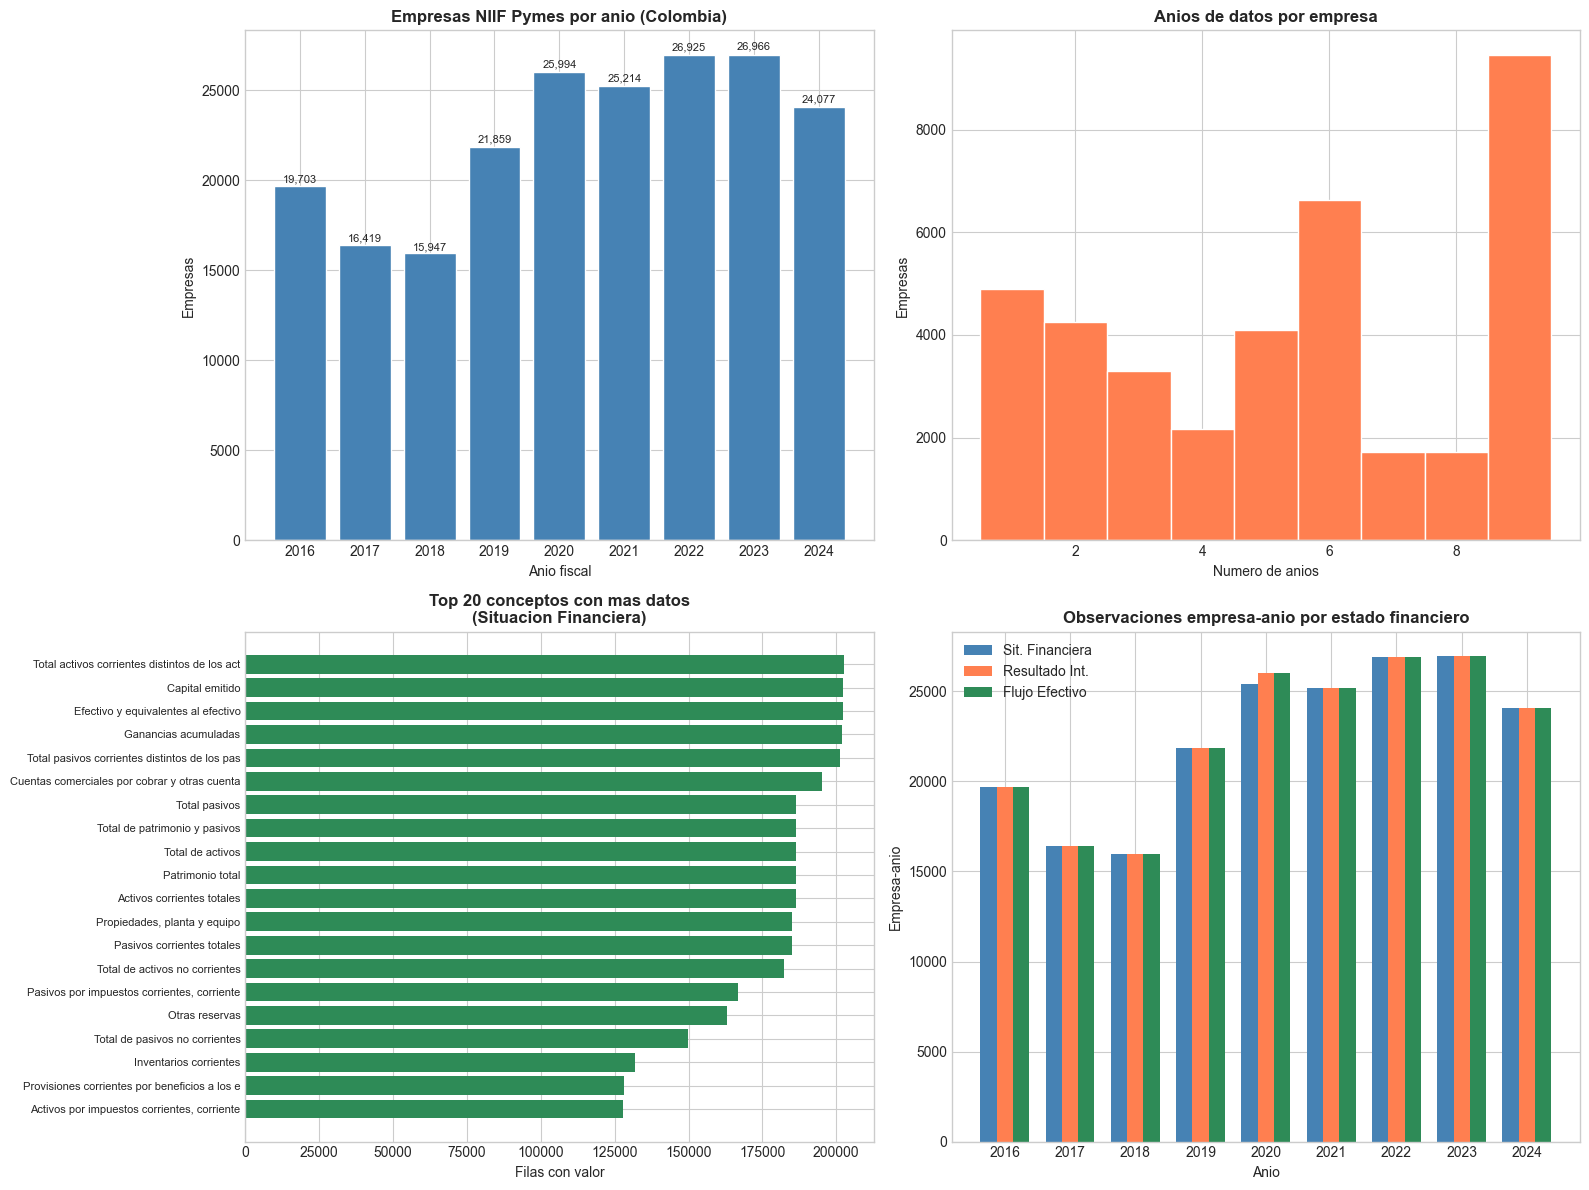

In [28]:
# ==============================================================================
# 7.4 VISUALIZACIONES
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Empresas por anio
ea = consolidado.groupby('ANIO')['NIT_LIMPIO'].nunique()
axes[0,0].bar(ea.index.astype(int).astype(str), ea.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Empresas NIIF Pymes por anio (Colombia)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Anio fiscal')
axes[0,0].set_ylabel('Empresas')
for i, v in enumerate(ea.values):
    axes[0,0].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=8)

# 2. Profundidad temporal
ae = consolidado.groupby('NIT_LIMPIO')['ANIO'].nunique()
axes[0,1].hist(ae, bins=range(1, ae.max()+2), color='coral', edgecolor='white', align='left')
axes[0,1].set_title('Anios de datos por empresa', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Numero de anios')
axes[0,1].set_ylabel('Empresas')

# 3. Completitud por estado financiero (top 20 conceptos del balance)
top_cols = pivotado_sf.iloc[:, 2:].notna().sum().sort_values(ascending=True).tail(20)
axes[1,0].barh(range(len(top_cols)), top_cols.values, color='seagreen')
axes[1,0].set_yticks(range(len(top_cols)))
axes[1,0].set_yticklabels([c[:45] for c in top_cols.index], fontsize=8)
axes[1,0].set_title('Top 20 conceptos con mas datos\n(Situacion Financiera)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Filas con valor')

# 4. Observaciones por anio (barras apiladas por estado)
sf_anio = pivotado_sf.groupby('ANIO').size()
ri_anio = pivotado_ri.groupby('ANIO').size()
fe_anio = pivotado_fe.groupby('ANIO').size()
anios_todos = sorted(set(sf_anio.index) | set(ri_anio.index) | set(fe_anio.index))
x = range(len(anios_todos))
w = 0.25
axes[1,1].bar([i-w for i in x], [sf_anio.get(a, 0) for a in anios_todos], w, label='Sit. Financiera', color='steelblue')
axes[1,1].bar(x, [ri_anio.get(a, 0) for a in anios_todos], w, label='Resultado Int.', color='coral')
axes[1,1].bar([i+w for i in x], [fe_anio.get(a, 0) for a in anios_todos], w, label='Flujo Efectivo', color='seagreen')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([str(int(a)) for a in anios_todos])
axes[1,1].set_title('Observaciones empresa-anio por estado financiero', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Anio')
axes[1,1].set_ylabel('Empresa-anio')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [29]:
# ==============================================================================
# 7.5 GUARDAR DATASET CONSOLIDADO
# ==============================================================================

print('GUARDADO DEL DATASET CONSOLIDADO')
print('=' * 70)

archivo_consolidado = SALIDA_PATH / 'colombia_consolidado_pymes.csv'
consolidado.to_csv(archivo_consolidado, index=False, encoding='utf-8')
tamano_mb = archivo_consolidado.stat().st_size / (1024**2)

print(f'\nArchivo: {archivo_consolidado.name}')
print(f'Tamano:  {tamano_mb:.1f} MB')
print(f'Filas:   {consolidado.shape[0]:,}')
print(f'Columnas: {consolidado.shape[1]}')

# Listar todos los archivos generados
print(f'\n\nTODOS LOS ARCHIVOS GENERADOS EN {SALIDA_PATH}')
print('=' * 70)
total_mb = 0
for archivo in sorted(SALIDA_PATH.glob('colombia_*_pymes.csv')):
    t = archivo.stat().st_size / (1024**2)
    total_mb += t
    print(f'  {archivo.name:<50s} {t:>8.1f} MB')
print(f'  {"TOTAL":<50s} {total_mb:>8.1f} MB')

GUARDADO DEL DATASET CONSOLIDADO

Archivo: colombia_consolidado_pymes.csv
Tamano:  213.7 MB
Filas:   203,104
Columnas: 230


TODOS LOS ARCHIVOS GENERADOS EN C:\Users\USUARIO1\Documents\Tesis\data
  colombia_consolidado_pymes.csv                        213.7 MB
  colombia_flujo_efectivo_pymes.csv                      48.9 MB
  colombia_metadata_pymes.csv                            15.5 MB
  colombia_resultado_integral_pymes.csv                  26.6 MB
  colombia_situacion_financiera_pymes.csv                62.4 MB
  TOTAL                                                 367.1 MB


---
## 8. Conclusiones y Próximos Pasos

### Proceso completado

1. **Carátula**: Metadatos (razón social, CIIU, municipio, etc.) extraídos para todas las empresas NIIF Pymes a nivel nacional.
2. **Situación Financiera**: Balance general pivotado — activos, pasivos, patrimonio de todas las PYMES (2016-2024).
3. **Resultado Integral**: Estado de pérdidas y ganancias pivotado — ingresos, costos, utilidades (2016-2024).
4. **Flujo de Efectivo**: Movimientos de efectivo pivotados — operación, inversión, financiación (2016-2024).
5. **Consolidación**: Dataset único con los 3 estados financieros + metadatos.

### Correcciones aplicadas (lecciones de notebooks anteriores)

| Problema | Solución |
|----------|----------|
| TAXONOMIA truncada para 2021+ ("Corte 202") | Usar FECHA_CORTE para extraer año fiscal |
| "Periodo Anterior" genera duplicación | Filtro inteligente de PERIODO |
| PERIODO con NITs en Flujo de Efectivo (2016) | Conservar como datos válidos con campo corrupto |
| Encoding de caracteres acentuados | latin-1 para estados financieros |

### Próximos pasos

| Paso | Descripción | Notebook |
|------|-------------|----------|
| 1 | **Validación con Ibagué**: cruzar con Cámara de Comercio para identificar las 61 empresas ibagüeñas | Separado |
| 2 | **Indicadores financieros**: calcular 18 indicadores (liquidez, rentabilidad, endeudamiento, eficiencia) | Siguiente |
| 3 | **Etiquetado de riesgo**: Z-Score de Altman + reglas heurísticas → Bajo/Medio/Alto | Siguiente |
| 4 | **Modelo ML**: Logística, Random Forest, XGBoost sobre dataset nacional | Siguiente |
| 5 | **Sistema web**: React + Node.js + PostgreSQL | Posterior |

In [30]:
# ==============================================================================
# RESUMEN FINAL
# ==============================================================================

print('=' * 70)
print('RESUMEN FINAL - ETL NACIONAL PYMES COLOMBIA')
print('=' * 70)

print(f'\nDATASET CONSOLIDADO:')
print(f'  Archivo:    colombia_consolidado_pymes.csv')
print(f'  Filas:      {consolidado.shape[0]:,} (observaciones empresa-anio)')
print(f'  Columnas:   {consolidado.shape[1]}')
print(f'  Empresas:   {consolidado["NIT_LIMPIO"].nunique():,}')
print(f'  Periodo:    {int(consolidado["ANIO"].min())} - {int(consolidado["ANIO"].max())}')

print(f'\nDATASETS INDIVIDUALES:')
print(f'  Metadatos:            {metadata.shape[0]:,} empresas x {metadata.shape[1]} cols')
print(f'  Situacion Financiera: {pivotado_sf.shape[0]:,} filas x {pivotado_sf.shape[1]} cols')
print(f'  Resultado Integral:   {pivotado_ri.shape[0]:,} filas x {pivotado_ri.shape[1]} cols')
print(f'  Flujo de Efectivo:    {pivotado_fe.shape[0]:,} filas x {pivotado_fe.shape[1]} cols')

print(f'\nARCHIVOS:')
for archivo in sorted(SALIDA_PATH.glob('colombia_*_pymes.csv')):
    t = archivo.stat().st_size / (1024**2)
    print(f'  {archivo.name}: {t:.1f} MB')

print(f'\n>>> Dataset nacional listo para calculo de indicadores financieros')
print(f'>>> Siguiente paso: validacion con empresas de Ibague (notebook separado)')

RESUMEN FINAL - ETL NACIONAL PYMES COLOMBIA

DATASET CONSOLIDADO:
  Archivo:    colombia_consolidado_pymes.csv
  Filas:      203,104 (observaciones empresa-anio)
  Columnas:   230
  Empresas:   38,245
  Periodo:    2016 - 2024

DATASETS INDIVIDUALES:
  Metadatos:            38,245 empresas x 25 cols
  Situacion Financiera: 202,501 filas x 82 cols
  Resultado Integral:   203,103 filas x 25 cols
  Flujo de Efectivo:    203,104 filas x 103 cols

ARCHIVOS:
  colombia_consolidado_pymes.csv: 213.7 MB
  colombia_flujo_efectivo_pymes.csv: 48.9 MB
  colombia_metadata_pymes.csv: 15.5 MB
  colombia_resultado_integral_pymes.csv: 26.6 MB
  colombia_situacion_financiera_pymes.csv: 62.4 MB

>>> Dataset nacional listo para calculo de indicadores financieros
>>> Siguiente paso: validacion con empresas de Ibague (notebook separado)
